# **European Drugs Development**

Team 10: Samuel Buelvas, Chamnan Suon, Gurveen Rekhi, Roberto Albornoz

## **Executive Summary**

Drug development in Europe plays a crucial role in shaping the pharmaceutical industry both in Europe and around the world. By understanding the behaviors of drug development stages and regulatory processes, we could uncover patterns and trends which would ultimately allow companies to better develop business strategies and adjust its internal process in order to optimize the successful implementation of the development.

Preliminary exploratory data analysis (EDA) was conducted on the European Medicines Agency (EMA) dataset to understand the portfolio structure and ensure the data support unsupervised learning. We began by examining authorization trends over time and expanding therapeutic area classifications to observe how the regulatory landscape has evolved. The time-series view highlights periods of acceleration and reveals whether surges in approvals are aligned with specific dominant disease areas or reflect broader diversification, directly informing our investigation into authorization trends.

Next, we assessed market concentration by identifying which marketing authorization holders account for the highest volume of medicines. This step determines whether approvals are broadly distributed across the industry or concentrated among a small group of firms. Understanding this distribution provides a baseline for segmenting companies in later stages, specifically to explore if certain portfolios or regulatory capabilities correlate with higher authorization accumulation.

Finally, we compared patterns between human and veterinary medicines and evaluated the variability of the unstructured indication text. We confirmed that the text descriptions contain sufficient length and diversity to support Natural Language Processing (NLP) tasks. This validates the project’s plan to use topic modeling to discover latent disease themes and niche clusters that are not fully captured by structured therapeutic labels alone.

## **Data Dictionary**

 `drugs_dataset.csv`

|Column  |Class      |Description          |
|:-------|:----------|:--------------------|
|category|character | human or veterinary|
|medicine_name | character | brand name of the medicine|
|therapeutic_area | character | semicolon-separated list of therapeutic areas|
|common_name | character | international non-proprietary name (INN) or common name|
|active_substance | character | common name of the active chemical in the drug|
|product_number | character | EMEA/H/C/ (human) or EMEA/V/C/ (veterinary) number for the drug|
|patient_safety | logical | has patient safety notices|
|authorisation_status | character | whether the drug was authorised, withdrawn, or refused (or does not have a reported status)|
|atc_code | character | anatomical therapeutic chemical code|
|additional_monitoring | logical | when true, the medicine is under additional monitoring, meaning that it is monitored even more intensively than other medicines|
|generic | logical | whether the drug is a generic medicine, which is developed to be the same as a medicine that has already been authorised, called the reference medicine. A generic medicine contains the same active substance(s) as the reference medicine, and is used at the same dose(s) to treat the same disease(s)|
|biosimilar | logical | whether the drug is a biosimilar medicine, which is a biological medicine highly similar to another already approved biological medicine called the reference medicine.|
|conditional_approval | logical | whether the medicine received a conditional marketing authorisation. This was granted in the interest of public health because the medicine addresses an unmet medical need and the benefit of immediate availability outweighs the risk from less comprehensive data than normally required.|
|exceptional_circumstances | logical | whether the medicine was authorised under exceptional circumstances, because the applicant was unable to provide comprehensive data on the efficacy and safety of the medicine under normal conditions of use. This can happen because the condition to be treated is rare or because collection of full information is not possible or is unethical.|
|accelerated_assessment | logical | whether the medicine had an accelerated assessment. This means that it is a medicine of major interest for public health, so its timeframe for review was 150 evaluation days rather than 210.|
|orphan_medicine | logical | whether the medicine was designated an orphan medicine. This means that it was developed for use against a rare, life-threatening or chronically debilitating condition or, for economic reasons, it would be unlikely to have been developed without incentives.|
|marketing_authorisation_date | date | date on which the drug was authorised|
|date_of_refusal_of_marketing_authorisation | date | date on which the drug was refused|
|marketing_authorisation_holder_company_name | character | name of the company that is authorised to market the drug|
|pharmacotherapeutic_group | character | the target of the drug|
|date_of_opinion | date | date on which the opinion was made|
|decision_date | date | date on which the latest decision was made|
|revision_number | integer | integer revision number|
|condition_indication | character | language describing the specific uses of the drug|
|species | character | for veterinary medicines, the target species; might benefit from further cleaning|
|first_published | datetime | datetime when the information was first published|
|revision_date | datetime | datetime of the most recent revision|
|url | character | url for details about the drug and submission|

## **Preprocessing**

In [1]:
# Import pandas and numpy for DataFrame and operations
import pandas as pd
import numpy as np

In [2]:
# Load dataset from github relative path
path = "https://raw.githubusercontent.com/SChamnan/ba820-unsupervised-ml-team10-project/refs/heads/main/european-drugs-development/drugs-dataset.csv"
drugs_df = pd.read_csv(path)
drugs_original=drugs_df.copy()
# Check out the first 5 rows of data
drugs_df.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


### **Data Cleaning and Preprocessing**

In [3]:
# Check number of rows and columns
drugs_df.shape

(1988, 28)

In [4]:
drugs_df.describe()

,product_number,revision_number
count,1988.000000,1892.000000
mean,2634.774145,13.527484
std,1915.734686,11.647056
min,24.000000,0.000000
25%,715.750000,4.750000
50%,2544.500000,11.000000
75%,4351.000000,19.000000
max,6039.000000,89.000000


Below shows number of missing values in each column. These missing values could be either removed or keep as they are. Imputation may not be the best option as it may misrepresenting data.

In [5]:
# Chart showing missing values of each column
missing_values = drugs_df.isnull().sum()
missing_percentage = ((drugs_df.isnull().sum() / len(drugs_df)) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_info.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
date_of_refusal_of_marketing_authorisation,1913,96.23
species,1709,85.97
date_of_opinion,779,39.19
therapeutic_area,285,14.34
revision_number,96,4.83
marketing_authorisation_date,60,3.02
decision_date,45,2.26
pharmacotherapeutic_group,34,1.71
revision_date,29,1.46
atc_code,28,1.41


In [6]:
# Information of values of the variable 'species'
unique_species_with_nan = drugs_df['species'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'species' column:")
print(unique_species_with_nan)


Unique values and their counts (including NaN) in 'species' column:
species
NaN                                                                    1709
Dogs                                                                     70
Cats                                                                     28
Pigs                                                                     25
Dogs; Cats                                                               18
Horses                                                                   18
Chicken                                                                  15
Cattle                                                                   10
Cattle; Pigs; Sheep                                                       7
Sheep; Cattle                                                             6
Cats; Dogs                                                                5
Sheep                                                                     5
Rabbits    

In [7]:
# Get the count of all unique values, including NaN, for 'authorisation_status'
unique_auth_status_with_nan = drugs_df['authorisation_status'].value_counts(dropna=False)
print("Unique values and their counts (including NaN) in 'authorisation_status' column:")
print(unique_auth_status_with_nan)

# You can apply the same to other columns as needed, for example 'category'
unique_category_with_nan = drugs_df['category'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'category' column:")
print(unique_category_with_nan)

Unique values and their counts (including NaN) in 'authorisation_status' column:
authorisation_status
authorised    1573
withdrawn      357
refused         57
NaN              1
Name: count, dtype: int64

Unique values and their counts (including NaN) in 'category' column:
category
human         1706
veterinary     282
Name: count, dtype: int64


### **Categorization of the Columns**

In [8]:
# Categorize columns type
# Category cols
cat_cols = ["category",
            "medicine_name",
            "common_name",
            "active_substance",
            "authorisation_status",
            "atc_code",
            "marketing_authorisation_holder_company_name"]

#text cols
text_cols = ["condition_indication"]

# id cols
id_cols = ["url", "product_number"]

# list text cols
list_text_cols = ["therapeutic_area",
                  "pharmacotherapeutic_group",
                  "species"]

# Numeric cols
numeric_cols = ["revision_number"]

# Boolean cols
boolean_cols = ["patient_safety",
                "additional_monitoring",
                "generic",
                "biosimilar",
                "conditional_approval",
                "exceptional_circumstances",
                "accelerated_assessment",
                "orphan_medicine",
                ]

# Datetime cols
datetime_cols = ["marketing_authorisation_date",
             "date_of_refusal_of_marketing_authorisation",
             "date_of_opinion",
             "decision_date",
             "revision_date",
             "first_published"]


### **Preparing data for Analysis**

In [9]:

def clean_string_series(s):
    """
    Standard string cleanup:
    - converts to pandas 'string' dtype
    - normalizes whitespace (multiple spaces -> one)
    - trims leading/trailing whitespace
    """
    s = s.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def to_bool_series(s):
    """
    Robust boolean conversion:
    Handles columns that might be stored as:
    - True/False
    - 1/0
    - 'TRUE'/'FALSE'
    - 'Yes'/'No'
    Missing values are treated as False (safe default for these regulatory flags).
    """
    if s.dtype == bool:
        return s.fillna(False)

    s_str = s.astype("string")
    s_norm = s_str.str.strip().str.lower()

    true_set = {"true", "t", "1", "yes", "y"}
    false_set = {"false", "f", "0", "no", "n", ""}

    out = pd.Series(pd.NA, index=s.index, dtype="boolean")
    out = out.mask(s_norm.isin(true_set), True)
    out = out.mask(s_norm.isin(false_set), False)

    # fallback numeric coercion for any remaining NAs
    if out.isna().any():
        num = pd.to_numeric(s_str, errors="coerce")
        out = out.fillna(num.eq(1))

    return out.fillna(False).astype(bool)

def clean_list_text_column(s):
    """
    Cleanup for semicolon-separated list fields like:
    therapeutic_area, pharmacotherapeutic_group, species.
    - normalizes whitespace
    - standardizes delimiter spacing: "A;B" -> "A; B"
    """
    s = clean_string_series(s)
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

def clean_species_column(s):
    """
    Extra cleanup for species:
    - removes parenthetical qualifiers: 'Pigs (for fattening)' -> 'Pigs'
    - standardizes semicolon spacing: 'Dogs;Cats' -> 'Dogs; Cats'
    """
    s = clean_list_text_column(s)
    s = s.str.replace(r"\s*\(.*?\)\s*", "", regex=True).str.strip()
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

**clean_string_series(s)**
This function cleans a text column in a consistent way. It converts the column to a string type, replaces multiple spaces with a single space, and removes extra spaces at the beginning and end of each value. This helps avoid errors caused by inconsistent spacing.

**to_bool_series(s)**
This function converts a column into True/False values even if the column is stored in different formats. It can handle values like True/False, 1/0, and text like "yes"/"no" or "true"/"false". Missing values are treated as False to keep regulatory flag columns safe and consistent for later analysis.

**clean_list_text_column(s)**
This function cleans columns that contain lists stored as text using semicolons (for example: "A;B"). It first applies basic text cleaning (spacing and trimming). Then it standardizes the semicolon format so items are separated as "; " (semicolon + one space). This makes splitting the list later more reliable.

**clean_species_column(s)**
This function is a specialized cleaner for the species column. It applies the semicolon list cleaning, removes extra text written inside parentheses (for example: "Pigs (for fattening)" becomes "Pigs"), and standardizes semicolon spacing again. This produces a cleaner and more consistent species field for later grouping and analysis.

### **Cleaning & Type casting columns**

In [10]:
drugs_df = drugs_df.copy()

# Clean category/text/id columns (trim + normalize spacing)
for c in (cat_cols + text_cols + id_cols):
    if c in drugs_df.columns:
        drugs_df[c] = clean_string_series(drugs_df[c])

# Clean list-text columns
for c in list_text_cols:
    if c in drugs_df.columns:
        if c == "species":
            drugs_df[c] = clean_species_column(drugs_df[c])
        else:
            drugs_df[c] = clean_list_text_column(drugs_df[c])

# Standardize small categorical fields
if "category" in drugs_df.columns:
    drugs_df["category"] = drugs_df["category"].astype("string").str.lower().str.strip()

if "authorisation_status" in drugs_df.columns:
    drugs_df["authorisation_status"] = drugs_df["authorisation_status"].astype("string").str.lower().str.strip()

if "atc_code" in drugs_df.columns:
    drugs_df["atc_code"] = drugs_df["atc_code"].astype("string").str.upper().str.strip()

# Cast booleans group
for c in boolean_cols:
    if c in drugs_df.columns:
        drugs_df[c] = to_bool_series(drugs_df[c])


# Cast numeric group
for c in numeric_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_numeric(drugs_df[c], errors="coerce").astype("Int64")


# Cast datetimes group
for c in datetime_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_datetime(drugs_df[c], errors="coerce")


# Quick checks
print("Category counts:\n", drugs_df["category"].value_counts(dropna=False), "\n")
print("Status counts:\n", drugs_df["authorisation_status"].value_counts(dropna=False), "\n")
if "species" in drugs_df.columns:
    print("Top species values:\n", drugs_df["species"].value_counts(dropna=False).head(10))


Category counts:
 category
human         1706
veterinary     282
Name: count, dtype: Int64 

Status counts:
 authorisation_status
authorised    1573
withdrawn      357
refused         57
<NA>             1
Name: count, dtype: Int64 

Top species values:
 species
<NA>                   1709
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: Int64


**Clean category/text/id columns**
Since text fields can include extra spaces or inconsistent spacing, we clean these columns by standardizing whitespace and trimming leading and trailing spaces.

**Clean list-text columns**
Since some fields store multiple values in one cell using semicolons, we standardize the formatting of these list-style columns so they are consistent. For species, we also remove text inside parentheses to keep the names clean.

**Standardize small categorical fields**
Since category and authorisation_status may appear with different capitalization or spaces, we convert them to lowercase and trim spaces. Since atc_code should follow a consistent code format, we convert it to uppercase and trim spaces.

**Cast columns (booleans, numeric, and datetime)**
Since some columns may be stored with inconsistent data types (for example, booleans as text, numbers as strings, or dates in mixed formats), we convert boolean, numeric, and datetime columns into consistent types. Any values that cannot be converted are set to missing to avoid errors in later analysis.

**Quick checks**
Since we want to confirm the cleaning worked, we print basic value counts for category, authorisation_status, and the most common species values.

### **Create Derived columns for Analysis**

In [11]:
# Shared / Computed derived columns
drugs_df["category_clean"] = drugs_df["category"].astype("string").str.strip().str.lower().fillna("unknown")
drugs_df["authorisation_status_clean"] = drugs_df["authorisation_status"].astype("string").str.strip().str.lower().fillna("unknown")

drugs_df["is_veterinary"] = (drugs_df["category_clean"] == "veterinary").astype(int)
drugs_df["is_authorised"] = (drugs_df["authorisation_status_clean"] == "authorised").astype(int)
drugs_df["is_withdrawn"]  = (drugs_df["authorisation_status_clean"] == "withdrawn").astype(int)
drugs_df["is_refused"]    = (drugs_df["authorisation_status_clean"] == "refused").astype(int)


# Map diseases being targeted (Indication NLP readiness)
drugs_df["condition_indication_clean"] = (
    drugs_df["condition_indication"]
      .fillna("")
      .astype("string")
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
      .str.lower()
)
drugs_df["indication_length"] = drugs_df["condition_indication_clean"].str.len().astype(int)

# Helpful for interpretation later
drugs_df["therapeutic_area_list"] = drugs_df["therapeutic_area"].apply(
    lambda x: [] if pd.isna(x) or str(x).strip() == ""
    else sorted(set([p.strip().lower() for p in str(x).split(";") if p.strip()]))
)
drugs_df["therapeutic_area_count"] = drugs_df["therapeutic_area_list"].apply(len).astype(int)
drugs_df["missing_therapeutic_area"] = drugs_df["therapeutic_area"].isna().astype(int)

drugs_df["atc_code_clean"] = drugs_df["atc_code"].astype("string").str.strip().str.upper()
drugs_df["atc_level1"] = drugs_df["atc_code_clean"].str[0]
drugs_df["atc_level2"] = drugs_df["atc_code_clean"].str[:3].where(drugs_df["atc_code_clean"].str.len() >= 3, pd.NA)
drugs_df["missing_atc_code"] = drugs_df["atc_code"].isna().astype(int)

# What types of medicines get special approvals?
pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

drugs_df["special_pathway_count"] = drugs_df[pathway_cols].sum(axis=1).astype(int)

def make_pathway_profile(row):
    active = [c for c in pathway_cols if bool(row[c])]
    return "+".join(active) if active else "none"

drugs_df["pathway_profile"] = drugs_df.apply(make_pathway_profile, axis=1)

# Human vs veterinary + veterinary species segmentation
drugs_df["species_clean"] = np.where(
    drugs_df["category_clean"] == "human",
    "human",
    drugs_df["species"].astype("string").str.strip()
)

drugs_df["missing_species_vet"] = (
    (drugs_df["category_clean"] == "veterinary") & (drugs_df["species_clean"].isna())
).astype(int)

drugs_df["species_clean"] = np.where(
    (drugs_df["category_clean"] == "veterinary") & (drugs_df["species_clean"].isna()),
    "unknown",
    drugs_df["species_clean"]
)

drugs_df["species_list"] = drugs_df["species_clean"].apply(
    lambda v: [] if pd.isna(v) or v in ["human", "unknown", ""]
    else sorted(set([p.strip().lower() for p in str(v).split(";") if p.strip()]))
)
drugs_df["species_count"] = drugs_df["species_list"].apply(len).astype(int)
drugs_df["multi_species_flag"] = (drugs_df["species_count"] > 1).astype(int)

# Quick checks
print("Derived status flag sum counts:\n",
      (drugs_df[["is_authorised", "is_withdrawn", "is_refused"]].sum(axis=1)).value_counts(dropna=False))

print("\nMissing species in veterinary rows:", drugs_df["missing_species_vet"].sum())
print("\nTop species_clean values:\n", drugs_df["species_clean"].value_counts(dropna=False).head(10))


Derived status flag sum counts:
 1    1987
0       1
Name: count, dtype: int64

Missing species in veterinary rows: 3

Top species_clean values:
 species_clean
human                  1706
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: int64


**Clean and standardize key categorical fields**
Since categories may have extra spaces or different capitalization, we create category_clean by trimming, converting to lowercase, and replacing missing values with "unknown" so values like “Human” and “human” are treated the same.

Since authorisation_status is used to compare outcomes across medicines, we create authorisation_status_clean by trimming, converting to lowercase, and replacing missing values with "unknown" to support reliable grouping and analysis.

**Create simple indicator (0/1) variables**
Since unsupervised methods work better with numeric inputs than text labels, we create is_veterinary as a 0/1 indicator based on category_clean.

Since we often need quick counts by status, we create is_authorised, is_withdrawn, and is_refused as 0/1 indicators from authorisation_status_clean, where "unknown" results in all three indicators being 0.

**Prepare indication text for NLP and quality checks**
Since condition_indication is free text with inconsistent spacing and casing, we create condition_indication_clean by filling missing values with an empty string, normalizing spaces, trimming, and converting to lowercase so it is ready for NLP steps.

Since indications can be very short or very long, we compute indication_length as the character length of condition_indication_clean to support basic checks and descriptive analysis.

**Therapeutic area processing**
Since therapeutic_area is stored as a semicolon-separated list, we create therapeutic_area_list by splitting on semicolons, trimming and lowercasing items, and removing duplicates to get a clean set of areas per medicine.

Since medicines can be linked to one or many therapeutic areas, we compute therapeutic_area_count to measure how many areas each medicine has.

Since missing therapeutic_area values may affect interpretation, we create missing_therapeutic_area as a 0/1 indicator to track where this field is absent.

**ATC code standardization and hierarchy**
Since ATC codes can have inconsistent formatting, we create atc_code_clean by trimming and converting to uppercase so codes match consistently.

Since ATC codes are hierarchical, we create atc_level1 (first character) and atc_level2 (first three characters) to support analysis at different levels.

Since some medicines may not have an ATC code recorded, we create missing_atc_code as a 0/1 indicator to track missingness.

**Special regulatory pathway features**
Since a medicine can have multiple pathway flags at the same time, we compute special_pathway_count by summing these flags to measure how many special pathways apply.

Since it is useful to interpret the exact combination of pathways, we create pathway_profile as a label listing all active pathway flags for each medicine.

**Species cleaning and veterinary segmentation**
Since species is not applicable for human medicines, we set species_clean to "human" when category_clean is "human" so it is not treated as missing.

Since some veterinary medicines have missing species values, we create missing_species_vet to flag veterinary rows where species is missing.

Since veterinary rows should have an explicit value even when species is missing, we replace missing veterinary species values with "unknown" in species_clean.

Since species may include multiple values separated by semicolons, we create species_list by splitting, trimming, lowercasing, and removing duplicates to form a clean list per medicine.

Since multi-species products may behave differently than single-species products, we compute species_count and multi_species_flag to measure and flag medicines that target more than one species.

**Quick checks**
Since we need to confirm the derived status flags behave as expected, we print the distribution of the sum of is_authorised, is_withdrawn, and is_refused to verify most rows have exactly one active status and "unknown" rows have zero.

Since we want to confirm veterinary species missingness is small and isolated, we print the total count of missing_species_vet.

Since we want a quick view of species after cleaning, we print the most common values in species_clean.

### **Data Overview After Cleaning**

In [12]:
# show size, missingness, imbalance, and what fields are “strong enough” to analyze.
# Shape
print("Rows, Columns:", drugs_df.shape)

# Missingness table (top missing)
missing = drugs_df.isna().mean().sort_values(ascending=False).to_frame("missing_pct")
missing["missing_pct"] = (missing["missing_pct"] * 100).round(2)
print(missing.head(15))

# Uniqueness checks
print("Unique product_number:", drugs_df["product_number"].nunique(dropna=False))
print("Unique url:", drugs_df["url"].nunique(dropna=False))

Rows, Columns: (1988, 50)
                                            missing_pct
date_of_refusal_of_marketing_authorisation        96.23
species                                           85.97
date_of_opinion                                   39.19
therapeutic_area                                  14.34
revision_number                                    4.83
marketing_authorisation_date                       3.02
decision_date                                      2.26
pharmacotherapeutic_group                          1.71
revision_date                                      1.46
atc_code                                           1.41
atc_level1                                         1.41
atc_level2                                         1.41
atc_code_clean                                     1.41
condition_indication                               0.60
common_name                                        0.20
Unique product_number: 1932
Unique url: 1988


In [13]:
drugs_df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,atc_level1,atc_level2,missing_atc_code,special_pathway_count,pathway_profile,species_clean,missing_species_vet,species_list,species_count,multi_species_flag
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,L,L01,0,1,orphan_medicine,human,0,[],0,0
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,A,A16,0,0,none,human,0,[],0,0
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,<NA>,<NA>,1,3,orphan_medicine+exceptional_circumstances+addi...,human,0,[],0,0
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,J,J06,0,1,additional_monitoring,human,0,[],0,0
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,L,L04,0,0,none,human,0,[],0,0


Dataset is cleaned and is ready for next steps.

## **Exploratory Data Analysis**

In [14]:
# Import libraries for plotting
import matplotlib.pyplot as plt

### **Authorized drugs trend over time**

Viewing trend of drugs being authorized to be marketed over time.

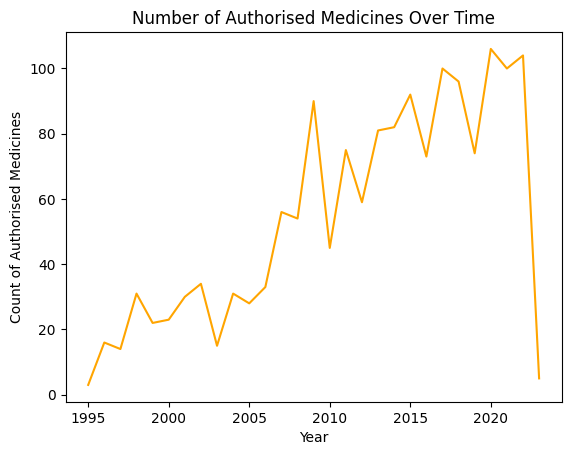

In [15]:
##### Check out drugs authorized drugs trend overtime #####
# Authorised medicines only
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

# Year of authorisation
authorised_df["authorised_year"] = authorised_df["marketing_authorisation_date"].dt.year

# Count per year (drop NaN years)
authorised_per_year = authorised_df["authorised_year"].dropna().value_counts().sort_index()

plt.figure()
authorised_per_year.plot(kind="line", color='orange')
plt.title("Number of Authorised Medicines Over Time")
plt.xlabel("Year")
plt.ylabel("Count of Authorised Medicines")
plt.show()

### **Top companies with most authorised medicines**

Viewing list of top 10 companies with the most authorized medicines.

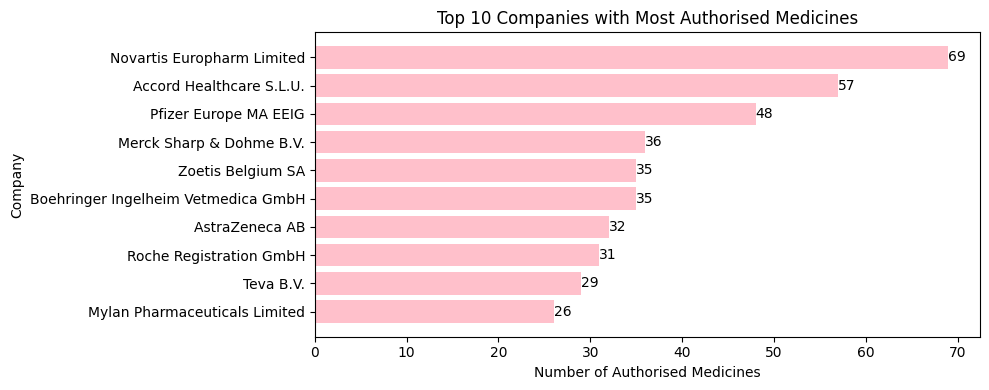

In [16]:
##### Check out companies with the most authorized medicines #####
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

company_counts = (
authorised_df["marketing_authorisation_holder_company_name"]
.value_counts()
.head(10)
.sort_values() # sort for barh readability
)

plt.figure(figsize=(10, 4))
plt.barh(company_counts.index, company_counts.values, color='pink')

# Add number on each bar for better readability
for i, v in enumerate(company_counts):
  plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Company")
plt.title("Top 10 Companies with Most Authorised Medicines")
plt.tight_layout()
plt.show()

### **Top therapeutic areas by authorised medicines**

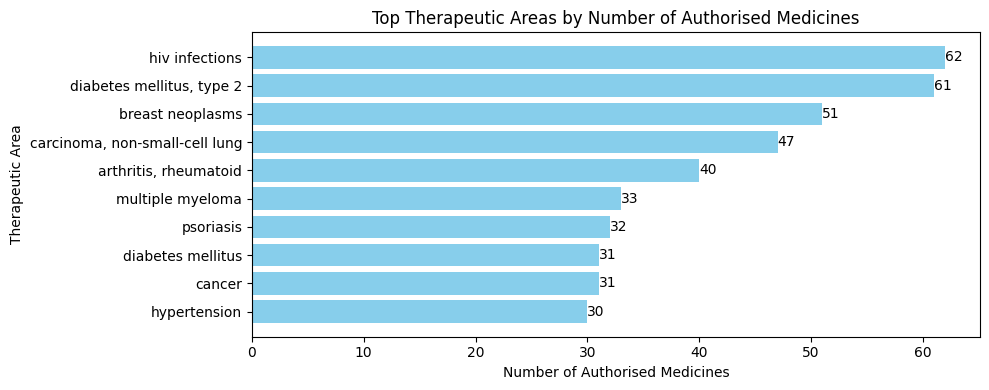

In [17]:
# Filter to get only authorized medicines
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

therapeutic_counts = (
authorised_df.explode("therapeutic_area_list")["therapeutic_area_list"]
.dropna()
.value_counts()
.head(10)
.sort_values()
)

# Plot bar graph
plt.figure(figsize=(10, 4))
plt.barh(therapeutic_counts.index, therapeutic_counts.values, color='skyblue')

# Add number on each bar for better readability
for i, v in enumerate(therapeutic_counts.values):
    plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Therapeutic Area")
plt.title("Top Therapeutic Areas by Number of Authorised Medicines")
plt.tight_layout()
plt.show()

### **Patterns of Special Approvals and Overlap**

builds on (1–3) by asking whether approvals are “standard” or concentrated in special regulatory pathways, and whether those pathways form natural profiles for segmentation.


Special-pathway flag prevalence (share of medicines):
additional_monitoring        19.47%
orphan_medicine               8.15%
accelerated_assessment        2.41%
conditional_approval          2.41%
exceptional_circumstances     2.41%
dtype: object

Distribution of special_pathway_count:
special_pathway_count
0    1500
1     338
2      96
3      53
4       1
Name: count, dtype: int64

Most common pathway profiles:
pathway_profile
none                                                                 1500
additional_monitoring                                                 251
orphan_medicine                                                        50
orphan_medicine+additional_monitoring                                  50
orphan_medicine+conditional_approval+additional_monitoring             26
accelerated_assessment                                                 24
orphan_medicine+exceptional_circumstances+additional_monitoring        18
conditional_approval+additional_monitoring       

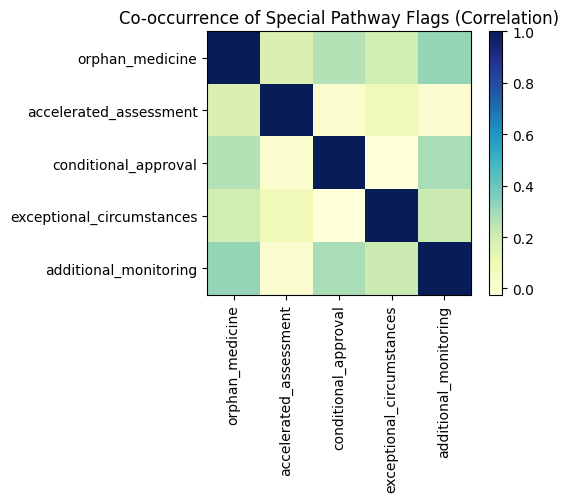

In [18]:

pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

# How common is each special pathway flag?
flag_rates = drugs_df[pathway_cols].mean().sort_values(ascending=False)
print("Special-pathway flag prevalence (share of medicines):")
print((flag_rates * 100).round(2).astype(str) + "%")

# How many special flags per medicine?
print("\nDistribution of special_pathway_count:")
print(drugs_df["special_pathway_count"].value_counts().sort_index())

# Most common pathway combinations
print("\nMost common pathway profiles:")
print(drugs_df["pathway_profile"].value_counts().head(15))

# Co-occurrence (do flags tend to appear together?)
corr = drugs_df[pathway_cols].astype(int).corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest", cmap="YlGnBu")
plt.xticks(range(len(pathway_cols)), pathway_cols, rotation=90)
plt.yticks(range(len(pathway_cols)), pathway_cols)
plt.title("Co-occurrence of Special Pathway Flags (Correlation)")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Special approvals look different across categories and species**

It compares the regulatory “signal” across human vs veterinary, then zooming into veterinary species segmentation.


Special-pathway flag rates by category (mean of boolean flags):
                orphan_medicine  accelerated_assessment  conditional_approval  \
category_clean                                                                  
human                     0.095                   0.023                 0.028   
veterinary                0.000                   0.028                 0.000   

                exceptional_circumstances  additional_monitoring  
category_clean                                                    
human                               0.026                  0.227  
veterinary                          0.011                  0.000  


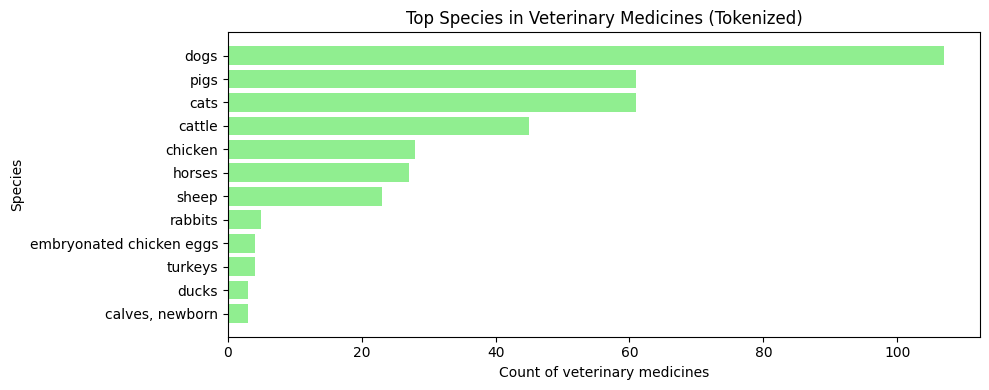


Share of veterinary medicines that target multiple species:
0.277


In [19]:

import matplotlib.pyplot as plt

pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

# Compare special-pathway rates across human vs veterinary
print("Special-pathway flag rates by category (mean of boolean flags):")
print(drugs_df.groupby("category_clean")[pathway_cols].mean().round(3))

# Veterinary-only: species distribution (tokenized list)
vet_df = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()

species_counts = (
    vet_df.explode("species_list")["species_list"]
    .dropna()
    .value_counts()
    .head(12)
    .sort_values()
)

plt.figure(figsize=(10, 4))
plt.barh(species_counts.index, species_counts.values, color="lightgreen")
plt.xlabel("Count of veterinary medicines")
plt.ylabel("Species")
plt.title("Top Species in Veterinary Medicines (Tokenized)")
plt.tight_layout()
plt.show()

# Multi-species structure (useful segmentation signal)
print("\nShare of veterinary medicines that target multiple species:")
print(vet_df["multi_species_flag"].mean().round(3))

### **Variability for NLP clustering**

Unstructured text that will power unsupervised discovery of disease/indication clusters.

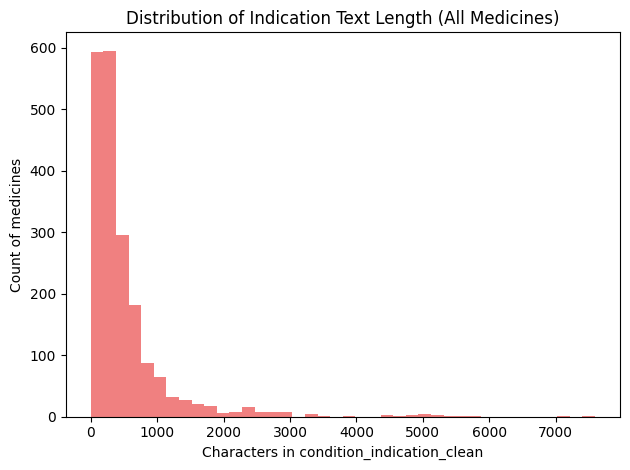


Indication length summary by category_clean:
                 count        mean    50%     max
category_clean                                   
human           1706.0  519.284877  299.5  7592.0
veterinary       282.0  431.574468  291.0  2513.0

Indication length summary by authorisation_status_clean:
                             count        mean    50%     max
authorisation_status_clean                                   
authorised                  1573.0  526.957406  311.0  7592.0
refused                       57.0  112.824561   40.0   971.0
unknown                        1.0    0.000000    0.0     0.0
withdrawn                    357.0  482.546218  301.0  4513.0

Top 25 words in authorised indication text:
[('with', 3636), ('and', 3403), ('the', 3314), ('for', 2839), ('treatment', 2527), ('patients', 2154), ('indicated', 2011), ('adult', 1088), ('who', 1018), ('combination', 956), ('have', 733), ('are', 603), ('therapy', 593), ('not', 572), ('adults', 541), ('years', 481), ('disea

In [20]:
from collections import Counter

# Distribution of text length
plt.figure()
plt.hist(drugs_df["indication_length"].dropna(), bins=40, color="lightcoral")
plt.title("Distribution of Indication Text Length (All Medicines)")
plt.xlabel("Characters in condition_indication_clean")
plt.ylabel("Count of medicines")
plt.tight_layout()
plt.show()

# Text length summaries by category and status
print("\nIndication length summary by category_clean:")
print(drugs_df.groupby("category_clean")["indication_length"].describe()[["count", "mean", "50%", "max"]])

print("\nIndication length summary by authorisation_status_clean:")
print(drugs_df.groupby("authorisation_status_clean")["indication_length"].describe()[["count", "mean", "50%", "max"]])

# Lightweight top-words check (gives intuition about recurring themes)
def top_words(series, n=25, min_len=3):
    words = []
    for txt in series:
        tokens = str(txt).split()
        tokens = [t for t in tokens if len(t) >= min_len]
        words.extend(tokens)
    return Counter(words).most_common(n)

authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()
withdrawn_df = drugs_df[drugs_df["authorisation_status_clean"] == "withdrawn"].copy()

print("\nTop 25 words in authorised indication text:")
print(top_words(authorised_df["condition_indication_clean"], n=25))

print("\nTop 25 words in withdrawn indication text:")
print(top_words(withdrawn_df["condition_indication_clean"], n=25))

## **Milestone 2**

In this second review the one of the lines of data interrogation is going to be explored into more detail. As a result of the initial EDA que following question: What patterns in regulatory characteristics and therapeutic areas agree with theo bserved increase in medicine authorizations between 2005 and 2010 and the subsequent decade?

Here is how my understanding of the problem evolved as I experimented with clustering:

### **Further feature engineering**
Some feature engineering is needed to apply unsupervise ML methods to make a more in depth research, it is presented below.

In [21]:
# Step 1
# Using a different dataframe to avoid damaging the already cleaned one
df = drugs_df.copy()

# Pre-selecting features
features = df[[
    "category",
    "therapeutic_area",
    "atc_code",
    "generic",
    "biosimilar",
    "conditional_approval",
    "exceptional_circumstances",
    "accelerated_assessment",
    "orphan_medicine",
    "additional_monitoring",
    "patient_safety",
    "authorisation_status",
    "marketing_authorisation_date"
]].copy() # Features that can represent similarity

# Step 2
# Columns to encode from boolean to dummy
bool_cols = [
    "generic",
    "biosimilar",
    "conditional_approval",
    "exceptional_circumstances",
    "accelerated_assessment",
    "orphan_medicine",
    "additional_monitoring",
    "patient_safety"
]
features[bool_cols] = features[bool_cols].astype(int)

# Step 3
# Creating a regulatory complexity score to capture intensity of regulatory oversight and special approval pathways
features["regulatory_complexity_score"] = (
    features["conditional_approval"]
    + features["exceptional_circumstances"]
    + features["accelerated_assessment"]
    + features["orphan_medicine"]
    + features["additional_monitoring"]
)

# Step 4
# Retrieving the most common therapeutic areas to find patterns on this dimention
features["therapeutic_area_list"] = (
    features["therapeutic_area"]
    .fillna("")
    .str.split(";")
)

from collections import Counter

# Counting therapeutic areas
area_counts = Counter(
    area.strip()
    for sublist in features["therapeutic_area_list"]
    for area in sublist if area
)

area_counts.most_common(15)

# Selecting the top 20 - there were 1988 different possible combinations, to avoid an exesive amount columns, most of those had only 1 observations
top_areas = [a for a, _ in area_counts.most_common(20)]

for area in top_areas:
    features[f"ta_{area}"] = features["therapeutic_area_list"].apply(
        lambda x: int(area in x)
    )
# Removing the features used for encoding
features.drop(columns=["therapeutic_area", "therapeutic_area_list"], inplace=True)

# Step 5
# Using ATC to retrieve important information about grouping
features["atc_lvl1"] = features["atc_code"].str[0]
features.drop(columns=["atc_code"], inplace=True)

# Generating dummies
features = pd.get_dummies(features, columns=["atc_lvl1"], prefix="atc")

# Step 6
# Distinguishing drugs for humans and animals
features = pd.get_dummies(features, columns=["category"], prefix="cat")

# Authorization status
features = pd.get_dummies(features, columns=["authorisation_status"], prefix="auth")
# Authorization status may reflect post-approval outcomes rather than intrinsic drug characteristics. I include it experimentally to its impact afterwards

# Step 7
# Retieving the year of authorization - the date itself can't be used for clustering
features["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year

features.drop(columns=["marketing_authorisation_date"], inplace=True)

# Step 8
# Filtering the data for clustering
X = features.drop(columns=["auth_year"])
X = X.fillna(0)

# Step 9
# Normalizing the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### **Trying Hierarchical clustering**

After transforming the potentially relevant categorical variables into dummies, creating the regulatory complexity index and the most common therapeutical areas.

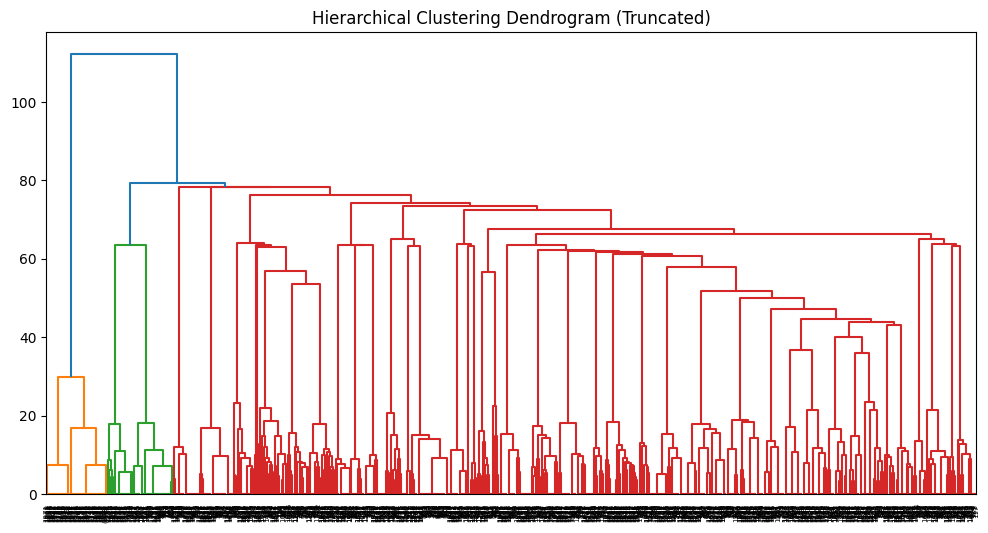

In [22]:
# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level")
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.show()


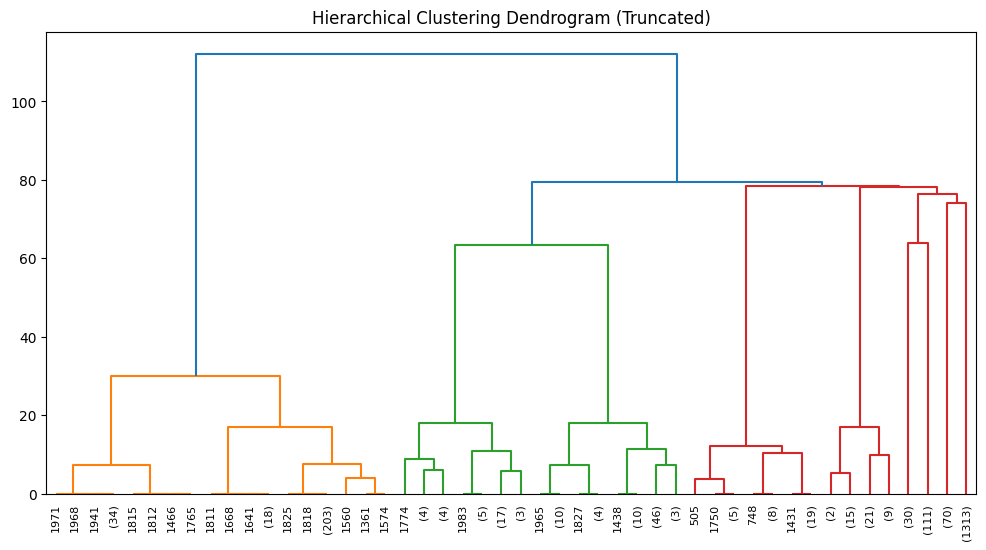

In [23]:
# Hierarchical clustering - Simplified version
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.show()


After reviewing the dendrogram showing the hierarchical clustering it looks like there is a natural aggreagation in 7 groups, considering that many high level merges occur between 70 and 80 in distance, which looks like good breaking point to contrast possible different enough groups. This grouping makes one of the clusters to have around 60\% of de data points, which seems very unbalanced.

Still, let's explore how does the clusters look like:

In [24]:
# From the dendogram a "natural" clustering seems to appear
n_clusters = 7
df['cluster_labels'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,atc_level2,missing_atc_code,special_pathway_count,pathway_profile,species_clean,missing_species_vet,species_list,species_count,multi_species_flag,cluster_labels
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,L01,0,1,orphan_medicine,human,0,[],0,0,7
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,A16,0,0,none,human,0,[],0,0,7
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,<NA>,1,3,orphan_medicine+exceptional_circumstances+addi...,human,0,[],0,0,5
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,J06,0,1,additional_monitoring,human,0,[],0,0,7
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,L04,0,0,none,human,0,[],0,0,7


In [25]:
df['cluster_labels'].value_counts()

,count
cluster_labels,
7,1313
1,270
5,141
2,111
6,70
4,47
3,36


In [26]:
# Creating a cross-tabulation of atc_level1 and cluster_labels
atc_cluster_crosstab = pd.crosstab( df['cluster_labels'],df['atc_level1'])
display(atc_cluster_crosstab)

atc_level1,A,B,C,D,G,H,J,L,M,N,P,Q,R,S,V
cluster_labels,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,1,0,267,0,0,0
2,111,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,36,0,0
4,0,0,47,0,0,0,0,0,0,0,0,0,0,0,0
5,17,9,4,0,0,2,17,59,5,6,2,8,1,3,3
6,0,0,0,0,0,0,0,0,0,70,0,0,0,0,0
7,73,126,44,18,59,38,236,404,49,110,0,3,32,31,69


The used clustering method is not necessarily reflecting the ATC classification system, this can be due to the features or method used to group the data, and only seems to capture (cluster) the typologies Q, A and R in a single aggregation.

In [27]:
# Generate a cross-tabulation of cluster_labels and regulatory_complexity_score
bool_cols=['conditional_approval','exceptional_circumstances','orphan_medicine','additional_monitoring']
df[bool_cols] = df[bool_cols].astype(int)
df["regulatory_complexity_score"] = (
    df["conditional_approval"]
    + df["exceptional_circumstances"]
    + df["accelerated_assessment"]
    + df["orphan_medicine"]
    + df["additional_monitoring"]
)
regulatory_complexity_crosstab = pd.crosstab(df['cluster_labels'], df['regulatory_complexity_score'])
display(regulatory_complexity_crosstab)

regulatory_complexity_score,0,1,2,3,4
cluster_labels,,,,,
1,270,0,0,0,0
2,101,10,0,0,0
3,26,10,0,0,0
4,46,1,0,0,0
5,18,33,39,50,1
6,68,2,0,0,0
7,971,282,57,3,0


The proposed complexity score also proven not to be the best way to differentiate between groups by using hierarchical clustering. Most of the drugs have a low regulatory complexity score, and those in a higher level doesn't seem to be similar enough to naturally group.

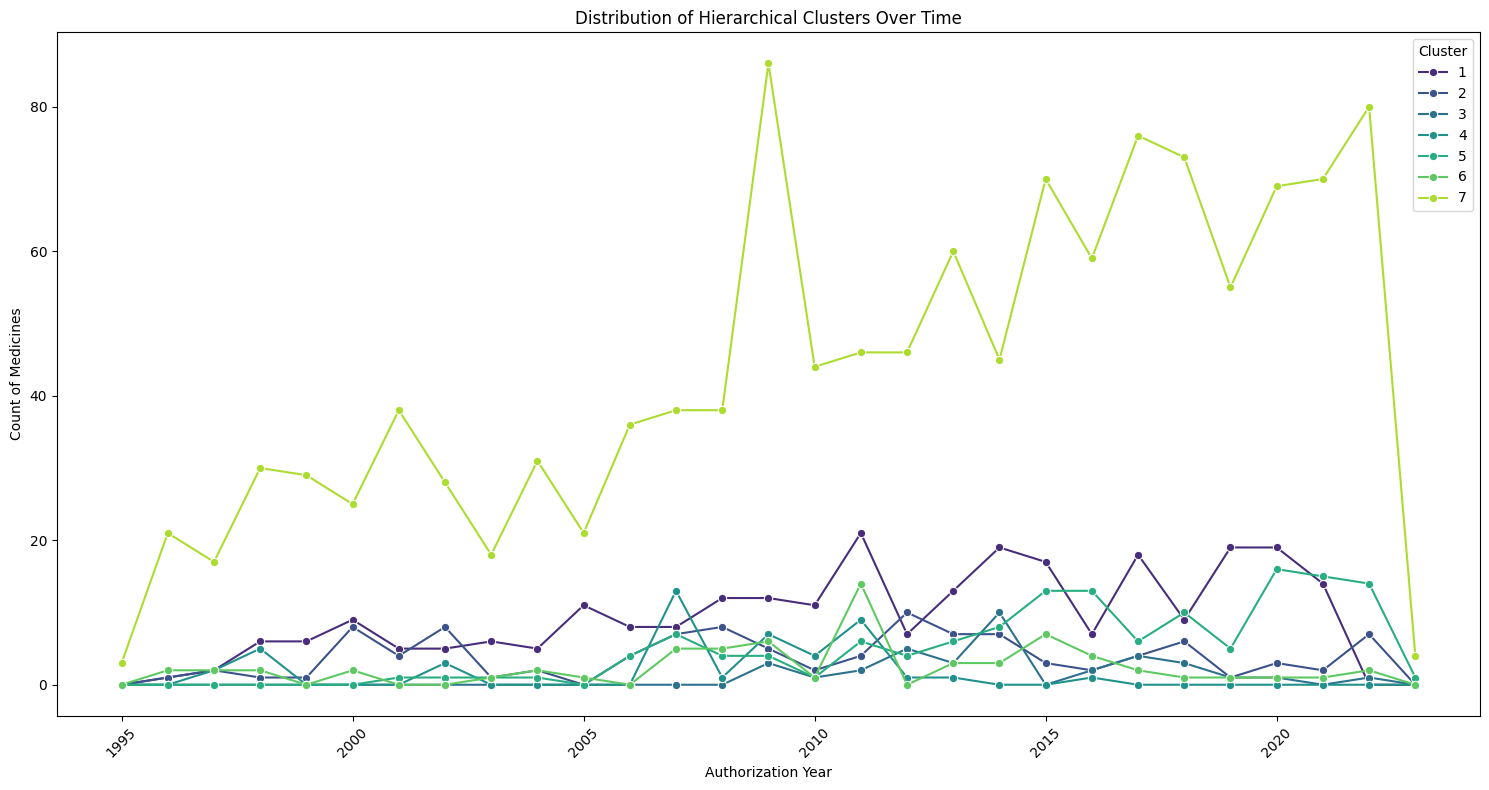

In [28]:
# Making a graph using the previous crosstab as base
import matplotlib.pyplot as plt
import seaborn as sns

df["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year

# Prepare data from the crosstab for plotting
crosstab_df = pd.crosstab(df["cluster_labels"], df["auth_year"])
plot_data = crosstab_df.stack().reset_index(name='count')
plot_data.rename(columns={'level_0': 'cluster_labels'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.lineplot(
    x='auth_year',
    y='count',
    hue='cluster_labels',
    data=plot_data,
    palette='viridis',
    marker='o' # Add markers for data points
)

plt.title('Distribution of Hierarchical Clusters Over Time')
plt.xlabel('Authorization Year')
plt.ylabel('Count of Medicines')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### **Trying K-Means Clustering**

Starting by checking the silhouette score and elbow method to determine the possible best number of clusters (k).

In [29]:
# Reseting the clustering labels
df = df.drop('cluster_labels',axis=1)

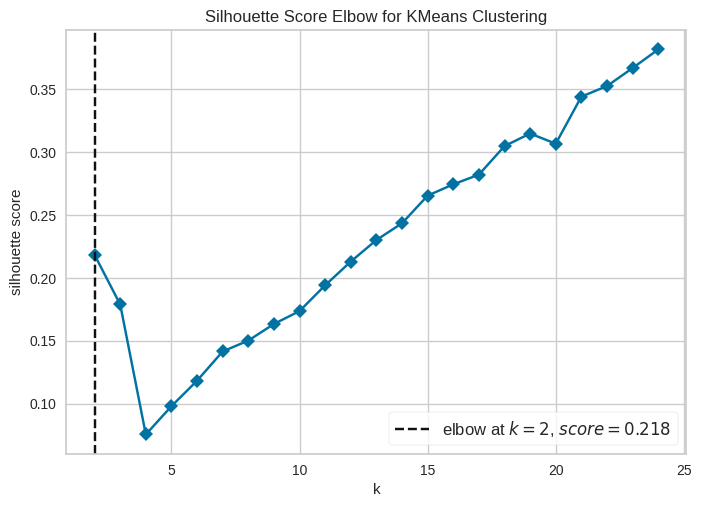

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [54]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 25), metric='silhouette', timings=False, random_state=42
)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

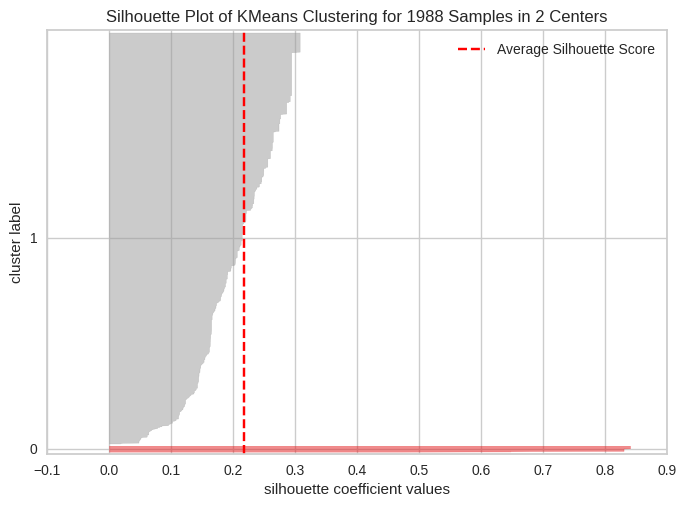

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [44]:
n_clusters_kmeans = 2

from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

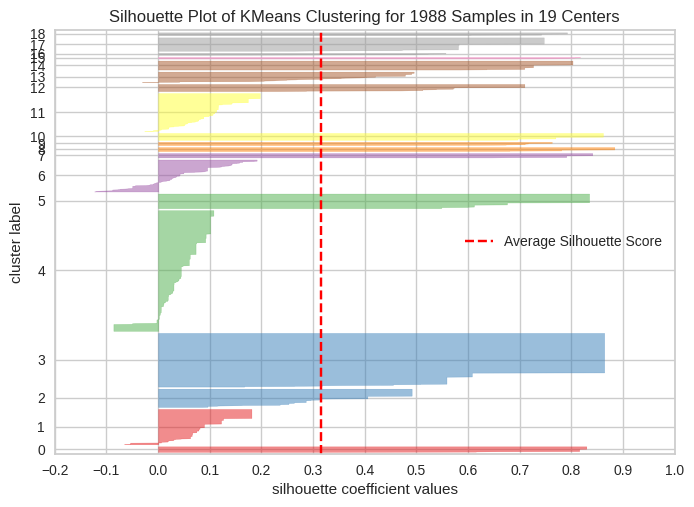

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 19 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [55]:
n_clusters_kmeans = 19

from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure

The silhouette score provides two possible number of clusters, by displaying 2 local maximumns, one at K=2 and one at K=19.

‎

From the silhouette plot its evident that increasing k provides more diverse clusters with low overlaping, while making a higher cut (k=2) don't provide enough differentiation between groups.

‎

To make a decision to choose a suitable K let's contrast this results with the elbow method.

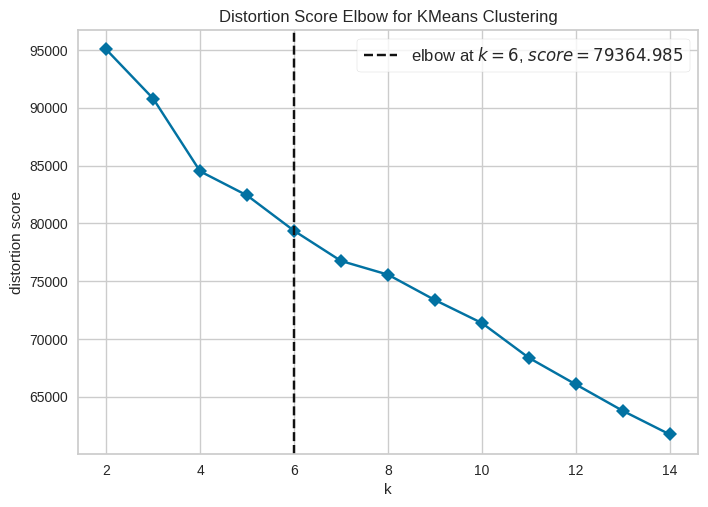

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [62]:
# Using the elbow method to determine the number of clusters
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering, k=(2, 15), metric='distortion', timings=False, random_state=42
)

visualizer.fit(X_scaled.values)      # Fit the data to the visualizer
visualizer.show()                    # Finalize and render the figure

The elbow method's function recommendation is K=6, but from the graph K=4 visually seems to be the true elbow. It would be consistent with the behavior observed in the silhouette plot. Let's explore K=4 and K=6.

#### **Trying K=4**

In [57]:
# Checking the clusters ditribution K=4
df["cluster_k4"] = KMeans(n_clusters=4, random_state=42, n_init=10)\
                    .fit_predict(X_scaled)
df['cluster_k4'].value_counts()

,count
cluster_k4,
1,1478
3,282
2,199
0,29


In [35]:
# Creating a cross-tabulation of atc_level1 and cluster_labels
atc_cluster_crosstab = pd.crosstab( df['cluster_k4'],df['atc_level1'])
display(atc_cluster_crosstab)

atc_level1,A,B,C,D,G,H,J,L,M,N,P,Q,R,S,V
cluster_k4,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,29,0,0,0,0,0
1,171,120,89,16,59,33,235,384,47,142,1,0,67,29,68
2,30,15,6,2,0,7,18,79,7,15,1,0,2,5,4
3,0,0,0,0,0,0,0,0,0,1,0,278,0,0,0


In [36]:
# Generate a cross-tabulation of cluster_labels and regulatory_complexity_score
bool_cols=['conditional_approval','exceptional_circumstances','orphan_medicine','additional_monitoring']
df[bool_cols] = df[bool_cols].astype(int)
df["regulatory_complexity_score"] = (
    df["conditional_approval"]
    + df["exceptional_circumstances"]
    + df["accelerated_assessment"]
    + df["orphan_medicine"]
    + df["additional_monitoring"]
)
regulatory_complexity_crosstab = pd.crosstab(df['cluster_k4'], df['regulatory_complexity_score'])
display(regulatory_complexity_crosstab)

regulatory_complexity_score,0,1,2,3,4
cluster_k4,,,,,
0,28,1,0,0,0
1,1198,280,0,0,0
2,0,52,93,53,1
3,274,5,3,0,0


In [37]:
# Checking persistence over time

df["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year

pd.crosstab(df["cluster_k4"], df["auth_year"])

auth_year,1995.0,1996.0,1997.0,1998.0,1999.0,2000.0,2001.0,2002.0,2003.0,2004.0,...,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
cluster_k4,,,,,,,,,,,,,,,,,,,,,
0,0,2,0,0,0,1,0,0,0,1,...,2,4,0,1,1,0,1,0,1,0
1,3,22,23,38,30,34,43,40,21,35,...,61,76,67,78,71,52,66,66,75,4
2,0,0,0,0,0,0,0,0,0,0,...,10,13,14,13,21,11,23,22,28,1
3,0,1,2,6,6,9,5,5,6,5,...,19,17,7,18,9,19,19,14,0,0


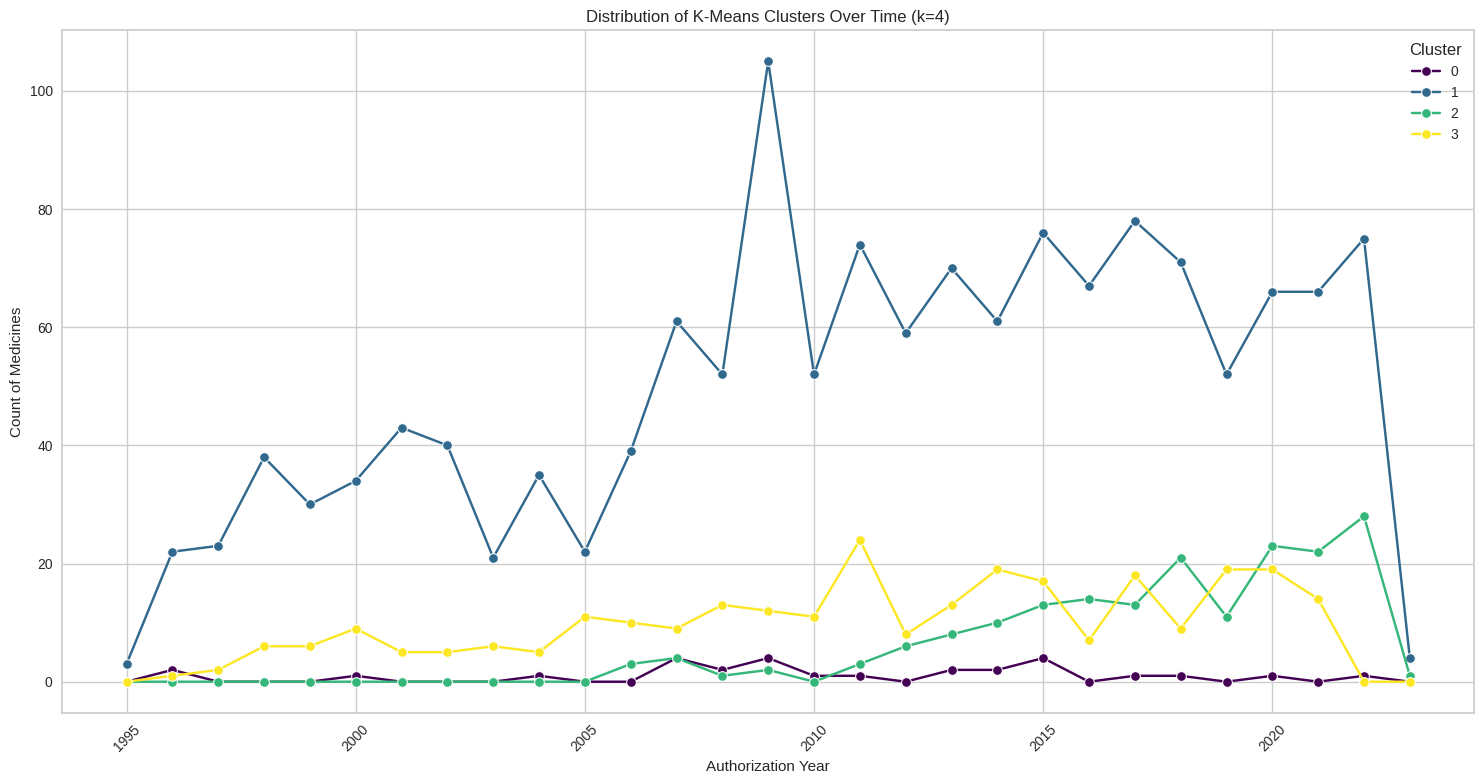

In [61]:
# Making a graph using the previous crosstab as base
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from the crosstab for plotting
crosstab_df = pd.crosstab(df["cluster_k4"], df["auth_year"])
plot_data = crosstab_df.stack().reset_index(name='count')
plot_data.rename(columns={'level_0': 'cluster_k4'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.lineplot(
    x='auth_year',
    y='count',
    hue='cluster_k4',
    data=plot_data,
    palette='viridis',
    marker='o' # Add markers for data points
)

plt.title('Distribution of K-Means Clusters Over Time (k=4)')
plt.xlabel('Authorization Year')
plt.ylabel('Count of Medicines')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

#### **Trying K=6**

In [72]:
# Checking the clusters ditribution K=6
df["cluster_k6"] = KMeans(n_clusters=6, random_state=42, n_init=10)\
                    .fit_predict(X_scaled)
df['cluster_k6'].value_counts()

,count
cluster_k6,
4,1405
0,282
1,155
5,76
2,47
3,23


In [71]:
# Creating a cross-tabulation of atc_level1 and cluster_labels
atc_cluster_crosstab = pd.crosstab( df['cluster_k6'],df['atc_level1'])
display(atc_cluster_crosstab)

atc_level1,A,B,C,D,G,H,J,L,M,N,P,Q,R,S,V
cluster_k6,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,1,0,278,0,0,0
1,24,12,4,1,0,5,18,58,6,12,1,0,2,3,2
2,0,0,47,0,0,0,0,0,0,0,0,0,0,0,0
3,0,23,0,0,0,0,0,0,0,0,0,0,0,0,0
4,101,100,44,17,59,35,235,405,48,174,1,0,67,31,70
5,76,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [70]:
# Generate a cross-tabulation of cluster_labels and regulatory_complexity_score
bool_cols=['conditional_approval','exceptional_circumstances','orphan_medicine','additional_monitoring']
df[bool_cols] = df[bool_cols].astype(int)
df["regulatory_complexity_score"] = (
    df["conditional_approval"]
    + df["exceptional_circumstances"]
    + df["accelerated_assessment"]
    + df["orphan_medicine"]
    + df["additional_monitoring"]
)
regulatory_complexity_crosstab = pd.crosstab(df['cluster_k6'], df['regulatory_complexity_score'])
display(regulatory_complexity_crosstab)

regulatory_complexity_score,0,1,2,3,4
cluster_k6,,,,,
0,274,5,3,0,0
1,0,8,93,53,1
2,46,1,0,0,0
3,23,0,0,0,0
4,1084,321,0,0,0
5,73,3,0,0,0


In [69]:
# Checking persistence over time
df["auth_year"] = pd.to_datetime(
    df["marketing_authorisation_date"],
    errors="coerce"
).dt.year
pd.crosstab(df["cluster_k6"], df["auth_year"])

auth_year,1995.0,1996.0,1997.0,1998.0,1999.0,2000.0,2001.0,2002.0,2003.0,2004.0,...,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0
cluster_k6,,,,,,,,,,,,,,,,,,,,,
0,0,1,2,6,6,9,5,5,6,5,...,19,17,7,18,9,19,19,14,0,0
1,0,0,0,0,0,0,0,0,0,0,...,8,10,10,7,17,9,21,21,26,1
2,0,0,2,5,0,0,0,3,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,24,21,32,30,30,40,37,20,36,...,59,80,68,84,73,53,68,66,73,4
5,0,0,0,1,0,5,3,0,1,0,...,6,3,2,1,3,1,1,1,5,0


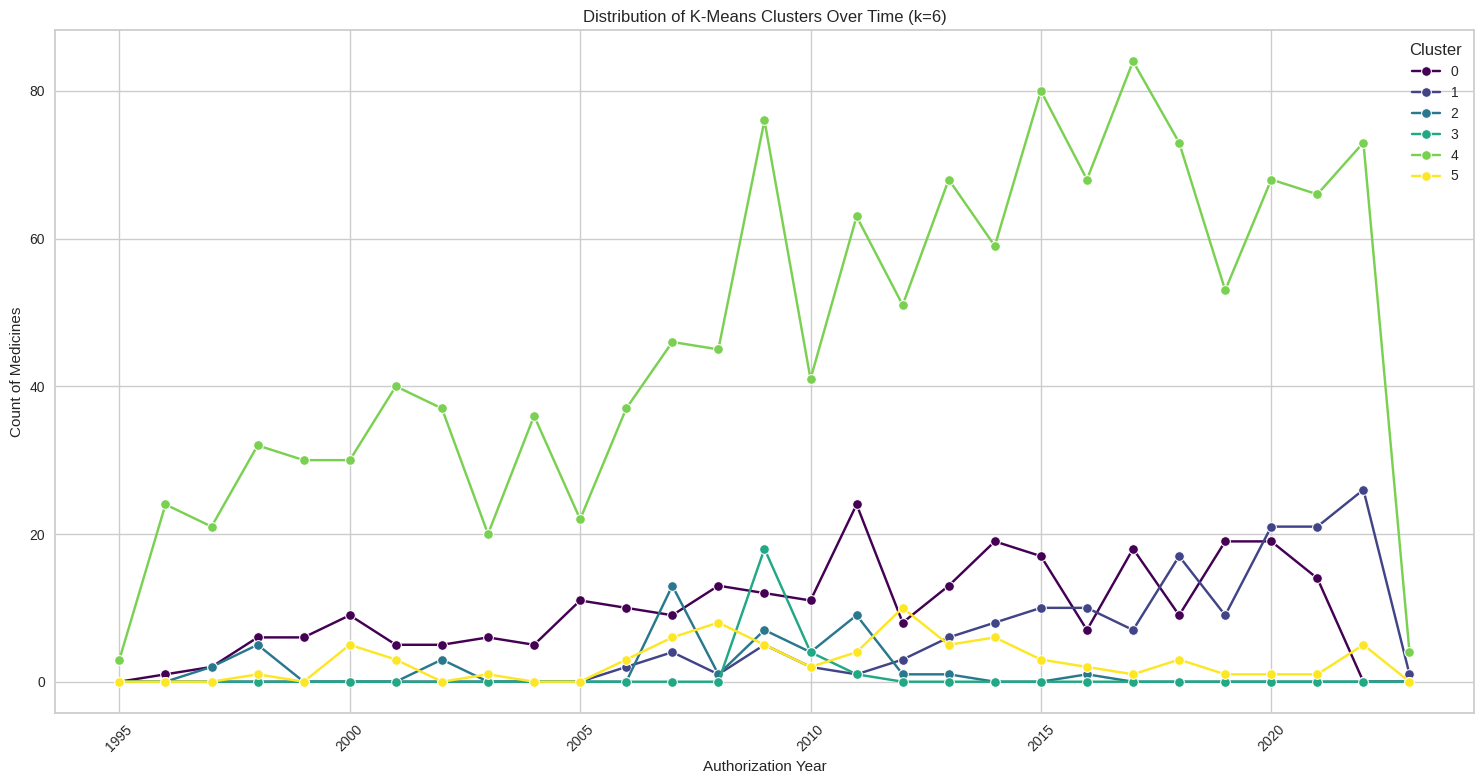

In [68]:
# Making a graph using the previous crosstab as base
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data from the crosstab for plotting
crosstab_df = pd.crosstab(df["cluster_k6"], df["auth_year"])
plot_data = crosstab_df.stack().reset_index(name='count')
plot_data.rename(columns={'level_0': 'cluster_k6'}, inplace=True)

plt.figure(figsize=(15, 8))
sns.lineplot(
    x='auth_year',
    y='count',
    hue='cluster_k6',
    data=plot_data,
    palette='viridis',
    marker='o' # Add markers for data points
)

plt.title('Distribution of K-Means Clusters Over Time (k=6)')
plt.xlabel('Authorization Year')
plt.ylabel('Count of Medicines')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### **Key Findings**
The clustering analyses conducted in this milestone reveal that medicines exhibit meaningful structure across regulatory and therapeutic dimensions, though this structure does not resolve into sharply separated or stable clusters. Hierarchical clustering indicates that medicines tend to group gradually rather than partition cleanly, suggesting that similarity operates along overlapping dimensions rather than discrete categories. K-means clustering reinforces this observation by demonstrating sensitivity to modeling assumptions and difficulty producing robust, interpretable partitions.

A consistent pattern across methods is the prominent role of regulatory characteristics in shaping similarity relationships. Medicines sharing similar regulatory pathways, such as orphan designation, accelerated assessment, or conditional approval, tend to cluster together even when their therapeutic areas differ. This suggests that regulatory treatment functions as a primary organizing dimension in the dataset, while therapeutic focus plays a more secondary, refining role within broader regulatory groupings.

Therapeutic information nonetheless contributes meaningful signal. Higher-level ATC groupings and multi-label therapeutic areas help differentiate medicines within regulatory profiles, but they rarely dominate cluster formation on their own. This diffuse contribution reflects both the broad nature of therapeutic categories and the limitations of representing clinical similarity using categorical labels alone.

Importantly, differences between clustering methods are treated as substantive insights rather than contradictions. The divergence between hierarchical and k-means results indicates that regulatory–therapeutic similarity in this dataset is continuous and multi-dimensional, rather than well approximated by centroid-based partitions. This methodological sensitivity informed a cautious interpretation of clusters as exploratory profiles rather than definitive segments.

Finally, because time variables were excluded from clustering, any variation in cluster prevalence across authorization years is treated as descriptive rather than causal. Preliminary inspection suggests that certain regulatory–therapeutic profiles become more or less common over time, supporting the revised framing of the analysis while avoiding premature conclusions about drivers of authorization trends.

### **Next Steps**
Several analytical steps remain open following this milestone.

* First, I plan to examine how the prevalence of identified regulatory–therapeutic profiles varies across time periods in order to descriptively contextualize observed authorization trends. Because time was excluded from clustering, this analysis will focus on changes in distribution rather than causal inference.

+ Second, I will assess the robustness of clustering results by modifying the feature set, including removing post-authorization outcome variables such as authorization status and testing alternative representations of regulatory intensity. This will help evaluate whether observed structure is driven by intrinsic regulatory characteristics or by downstream outcomes.

* Third, future milestones will explore richer representations of therapeutic similarity. Potential approaches include dimensionality reduction methods or refined text-based embeddings of disease indications, which may better capture clinical nuance than categorical therapeutic labels.

* Finally, insights from these analyses will inform whether clustering outputs can be meaningfully linked to downstream questions about regulatory strategy or policy context, while maintaining appropriate caution regarding interpretation.